<a href="https://colab.research.google.com/github/maryanamelnyk-png/matplotlib-data-visualization/blob/main/visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

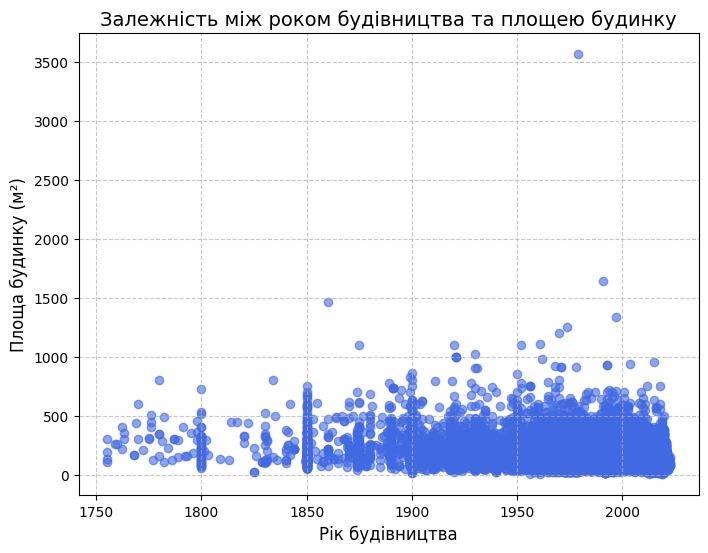

In [ ]:
#Імпорт файлу
import pandas as pd
import matplotlib.pyplot as plt

file_id = "1l_RLwk93ZP35Qr-guJwSY7APtDGLL_tZ"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)

#Побудова scatter plot

plt.figure(figsize=(8,6))
plt.scatter(df['construction_year'], df['house_area'], marker='o', color='royalblue', alpha=0.6)

plt.title('Залежність між роком будівництва та площею будинку', fontsize=14)
plt.xlabel('Рік будівництва', fontsize=12)
plt.ylabel('Площа будинку (м²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


/tmp/ipython-input-81536972.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_group', as_index=False)['house_area'].mean()


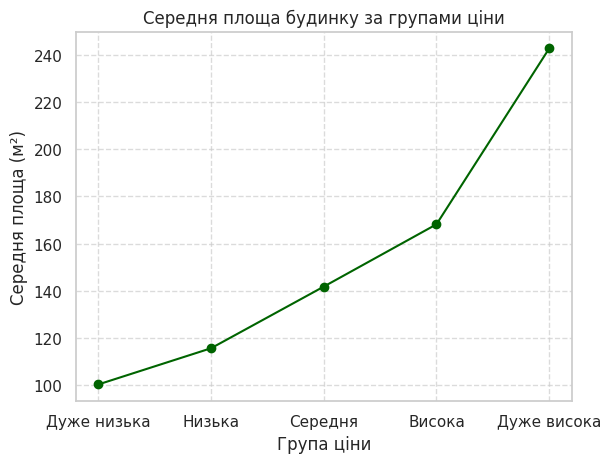

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Очищення даних, заміна нечислових значень
df['price'] = (df['price'].astype(str).str.replace('[€,]', '', regex=True).str.strip())
df['price'] = pd.to_numeric(df['price'], errors='coerce')

#Видалення пропусків
df = df.dropna(subset=['price', 'house_area'])

#Створення 5 рівнів груп цін
df['price_group'] = pd.qcut(df['price'], 5, labels=['Дуже низька','Низька','Середня','Висока','Дуже висока'])

#Групування та обчислення середньої площі для кожної групи
grouped = df.groupby('price_group', as_index=False)['house_area'].mean()

#Побудова графіку
plt.plot(grouped['price_group'], grouped['house_area'], marker='o', color='darkgreen')
plt.title('Середня площа будинку за групами ціни')
plt.xlabel('Група ціни')
plt.ylabel('Середня площа (м²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


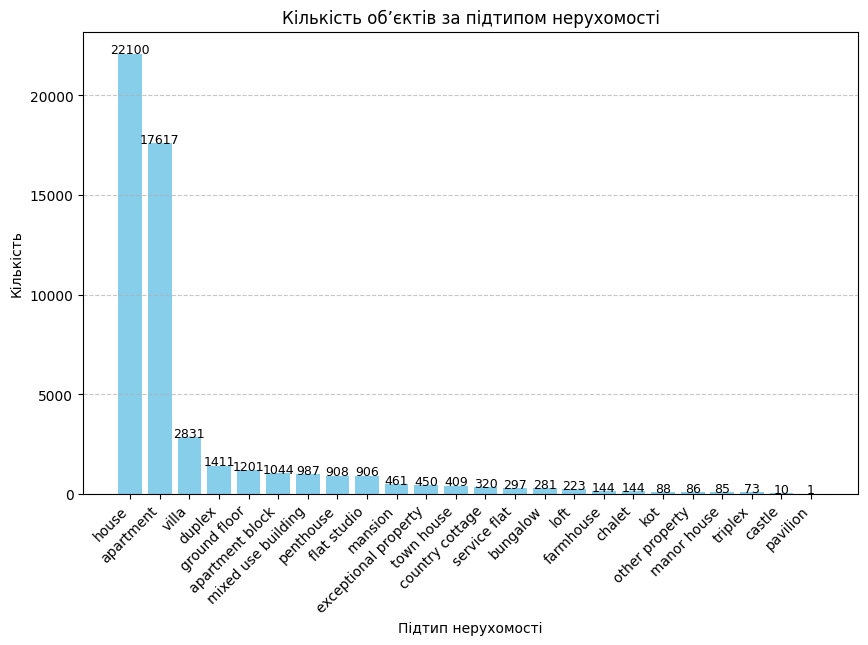

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Прибрати пробіли у назвах колонок
df.columns = df.columns.str.strip()

#Скільки разів зустрічається кожен підтип нерухомості
counts = df['subtype_of_property'].value_counts()

#Побудова bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values, color='skyblue')

#Додавання значень над кожним стовпчиком
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=9)

#Побудова графіку
plt.title('Кількість об’єктів за підтипом нерухомості')
plt.xlabel('Підтип нерухомості')
plt.ylabel('Кількість')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

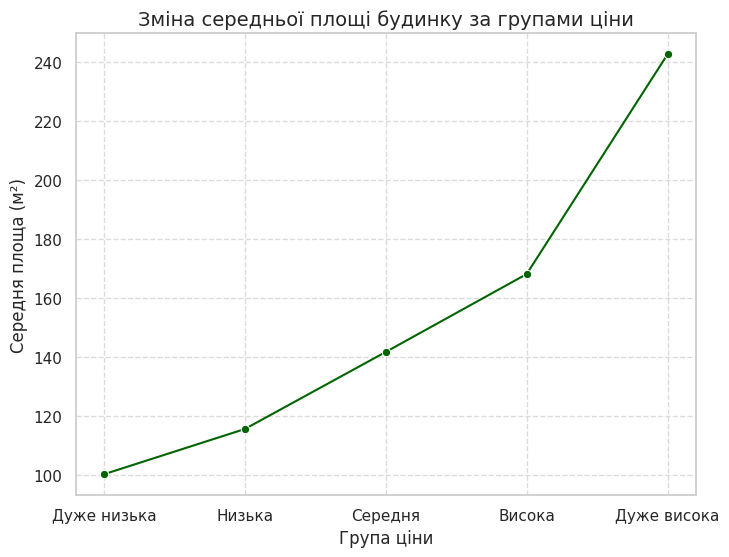

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Побудова lineplot у Seaborn
plt.figure(figsize=(8,6))
sns.lineplot(data=grouped, x='price_group', y='house_area', marker='o', color='darkgreen')

plt.title('Зміна середньої площі будинку за групами ціни', fontsize=14)
plt.xlabel('Група ціни', fontsize=12)
plt.ylabel('Середня площа (м²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


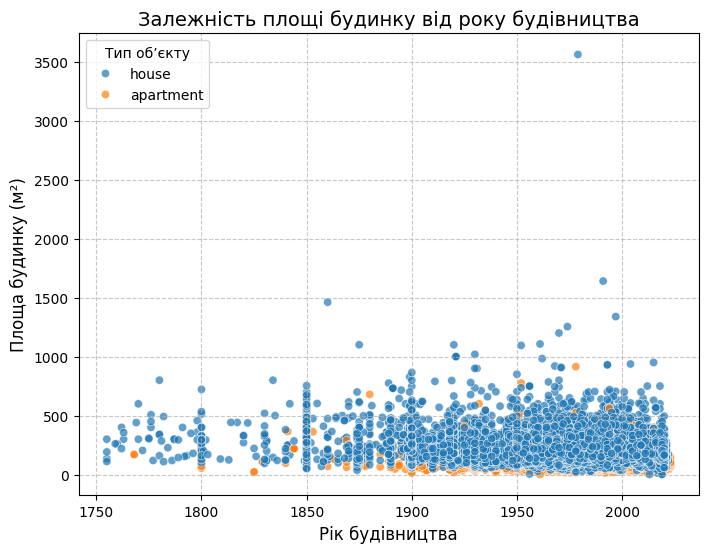

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Видалення пропусків у відповідних стовпцях
df = df.dropna(subset=['construction_year', 'house_area', 'type_of_property'])

#Побудова scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='construction_year', y='house_area', hue='type_of_property', alpha=0.7)

plt.title('Залежність площі будинку від року будівництва', fontsize=14)
plt.xlabel('Рік будівництва', fontsize=12)
plt.ylabel('Площа будинку (м²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Тип об’єкту')
plt.show()



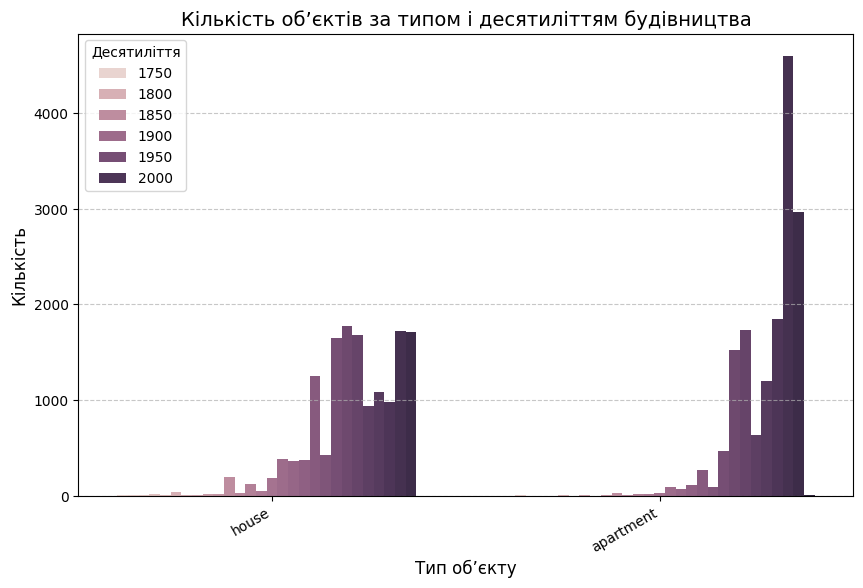

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Видалення пропусків у відповідних стовпцях
df = df.dropna(subset=['type_of_property', 'construction_year'])

#Додовання нового стовпця з десятиліттями
df['decade'] = (df['construction_year'] // 10) * 10

#Побудова countplot
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='type_of_property', hue='decade')

plt.title('Кількість об’єктів за типом і десятиліттям будівництва', fontsize=14)
plt.xlabel('Тип об’єкту', fontsize=12)
plt.ylabel('Кількість', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Десятиліття')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipython-input-2324716493.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type_of_property', y='price', palette='Set2')


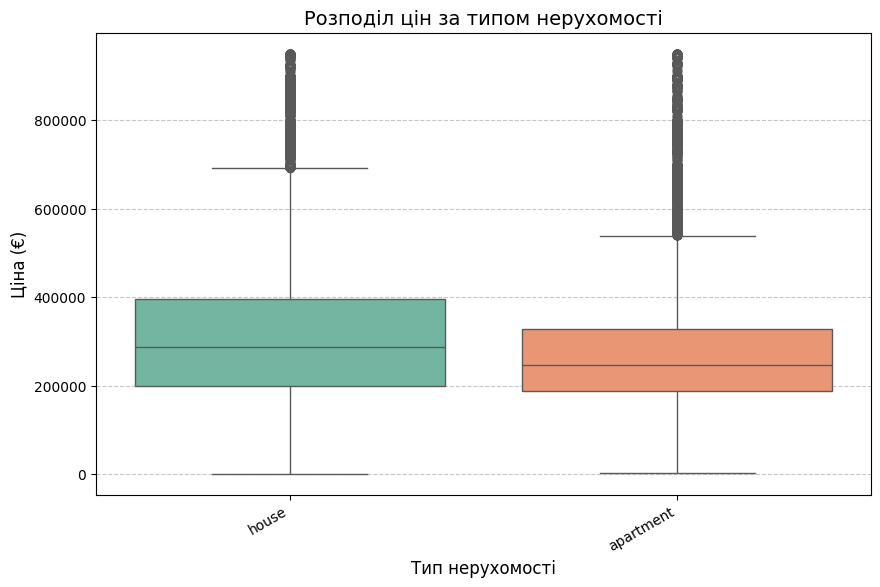

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Очищення даних, заміна нечислових значень
df['price'] = (df['price'].astype(str).str.replace('[€,]', '', regex=True).str.replace('no price', '', case=False).str.strip())
df['price'] = pd.to_numeric(df['price'], errors='coerce')

#Видалення пропусків
df = df.dropna(subset=['price', 'type_of_property'])

#Побудова boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='type_of_property', y='price', palette='Set2')

plt.title('Розподіл цін за типом нерухомості', fontsize=14)
plt.xlabel('Тип нерухомості', fontsize=12)
plt.ylabel('Ціна (€)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipython-input-1300166380.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Локація')


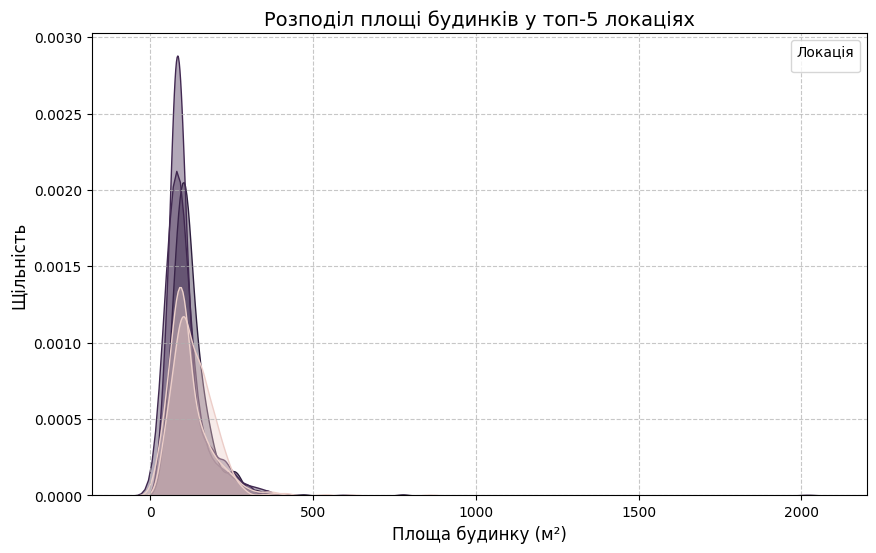

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Видалення пропусків
df = df.dropna(subset=['locality', 'house_area'])

#Топ-5 найбільш популярних локацій
top5 = df['locality'].value_counts().nlargest(5).index
df_top5 = df[df['locality'].isin(top5)]

#Побудова kdeplot
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_top5, x='house_area', hue='locality', fill=True, alpha=0.4)

plt.title('Розподіл площі будинків у топ-5 локаціях', fontsize=14)
plt.xlabel('Площа будинку (м²)', fontsize=12)
plt.ylabel('Щільність', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Локація')
plt.show()


In [ ]:
import seaborn as sns

# Для перегляду на ноутбуці
sns.set_style("whitegrid")   #світлий фон і сітка — зручно для друку,публікацій
sns.set_context("notebook")  #стандартний масштаб елементів

# Для презентації (можна активувати замість попереднього)
# sns.set_style("darkgrid")   #темна сітка на сірому фоні
# sns.set_context("talk")     #більший шрифт для слайдів, зручно для презентації
